# Initial analysis of data

This notebook presents the initial analysis done on the preprocessed data to find areas of intrest

## 1. Load modules and data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../dataset/training_data_processed.csv')

print(df.head(5))

   Unnamed: 0                                              title  \
0           0  The President's News Conference in Hanoi, Vietnam   
1           1  The President's News Conference in Hanoi, Vietnam   
2           2  The President's News Conference in Hanoi, Vietnam   
3           3  The President's News Conference in Hanoi, Vietnam   
4           4  The President's News Conference in Hanoi, Vietnam   

                 date        president  question_order  \
0  September 10, 2023  Joseph R. Biden               1   
1  September 10, 2023  Joseph R. Biden               1   
2  September 10, 2023  Joseph R. Biden               2   
3  September 10, 2023  Joseph R. Biden               2   
4  September 10, 2023  Joseph R. Biden               3   

                                  interview_question  \
0  Q. Of the Biden administration. And accused th...   
1  Q. Of the Biden administration. And accused th...   
2  Q. No worries. Do you believe the country's sl...   
3  Q. No worries. 

## 2. Attribute analysis

### 2.1 Reply length

Start by analysing the lenght and spread of length of questions and answers

In [5]:
df["q_len"] = df["question"].str.split().str.len()
df["a_len"] = df["answer"].str.split().str.len()

print(df[["q_len", "a_len"]].describe())

             q_len        a_len
count  3448.000000  2112.000000
mean     14.462007    42.145833
std       8.833190    43.901968
min       1.000000     1.000000
25%       8.000000    15.000000
50%      12.000000    27.000000
75%      19.000000    56.000000
max      80.000000   371.000000


Add plots to make more clear

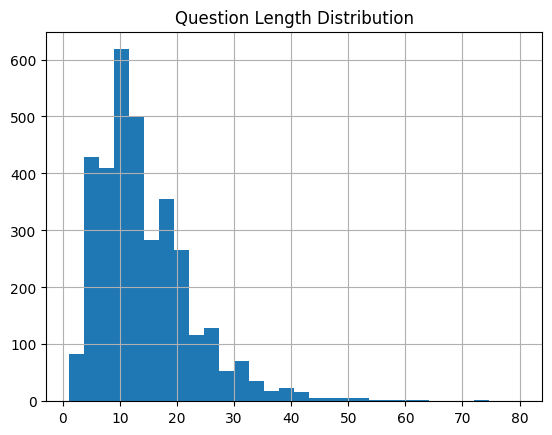

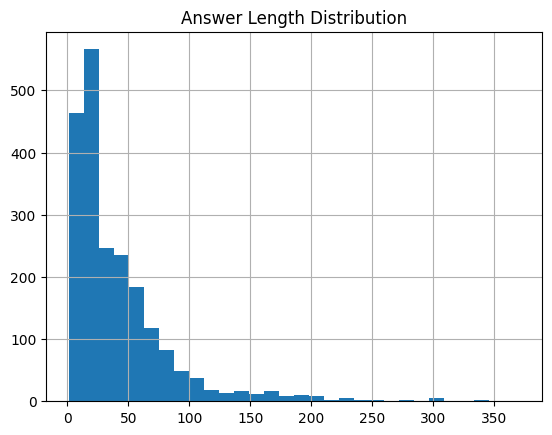

In [6]:
df["q_len"].hist(bins=30)
plt.title("Question Length Distribution")
plt.show()

df["a_len"].hist(bins=30)
plt.title("Answer Length Distribution")
plt.show()

Check if lenght of answer is correlated with type of reply

In [7]:
df['answer_len'] = df['answer'].str.split().str.len()

df.groupby('clarity_label')['answer_len'].describe()


,count,mean,std,min,25%,50%,75%,max
clarity_label,,,,,,,,
Ambivalent,1192.0,44.137584,45.955747,2.0,15.0,29.0,57.0,371.0
Clear Non-Reply,234.0,35.123932,30.032844,3.0,15.0,26.5,43.0,205.0
Clear Reply,686.0,41.080175,44.000507,1.0,13.0,23.0,56.0,303.0


Plot boxplots and histograms as well

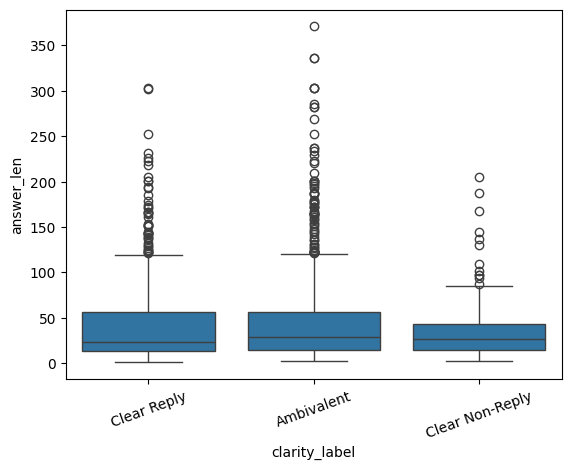

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='clarity_label', y='answer_len')
plt.xticks(rotation=20)
plt.show()

<Axes: xlabel='answer_len', ylabel='Density'>

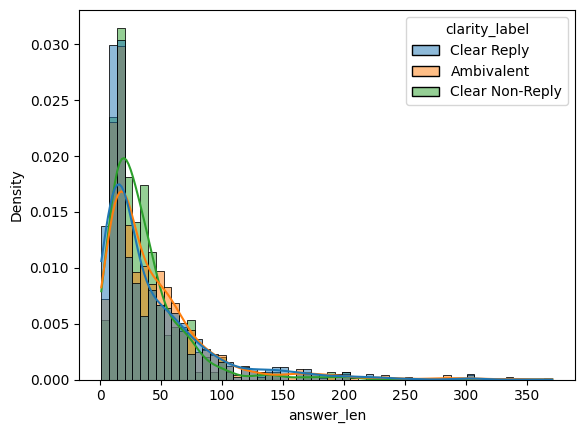

In [11]:
sns.histplot(
    data=df,
    x="answer_len",
    hue="clarity_label",
    stat="density",
    common_norm=False,  
    kde=True
)

Analyzing president for diffrent trendsw. (although president is not a trainsble attribute?)

In [12]:
df["clarity_label"].value_counts(normalize=True)
df["evasion_label"].value_counts(normalize=True)

df.groupby("president")["clarity_label"].value_counts(normalize=True)

president        clarity_label  
Barack Obama     Ambivalent         0.681188
                 Clear Reply        0.223762
                 Clear Non-Reply    0.095050
Donald J. Trump  Ambivalent         0.556226
                 Clear Reply        0.326038
                 Clear Non-Reply    0.117736
George W. Bush   Ambivalent         0.570028
                 Clear Reply        0.343137
                 Clear Non-Reply    0.086835
Joseph R. Biden  Ambivalent         0.521303
                 Clear Reply        0.373434
                 Clear Non-Reply    0.105263
Name: proportion, dtype: float64

No clear differencew between the classes can be obsereved. Moving on to other metreics...

### 2.2 Sentiment analysis and word count

Start by importing vital modules

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


Start by cluster analysis of topics using KMeans

In [14]:
custom_stops = {
    "president", "mr", "mrs", 
    "biden", "trump","obama", "bush" ,"sir",
    "administration",
    "american", "americans",
    "united", "states",
    "u", "s", "us"
}

vec = TfidfVectorizer(stop_words='english',ngram_range=(1,2), max_df=0.8, min_df=5)
# Remove custom stopwords after tokenization
def remove_custom(text):
    return " ".join(
        word for word in text.lower().split() 
        if word not in custom_stops
    )


df["clean_question"] = df["question"].apply(remove_custom)

X = vec.fit_transform(df['clean_question'])

k = 8

model = KMeans(n_clusters=k, random_state=0).fit(X)
df['question_topic'] = model.labels_

Print out the top words for each topic

In [15]:
terms = vec.get_feature_names_out()
for i in range(k):
    inds = model.cluster_centers_[i].argsort()[-15:]
    print(f"Topic {i}:", ", ".join(terms[ind] for ind in inds))

Topic 0: possibility, qadhafi, prepared, given, currently, sanctions, asad, public, new, election, presidency, end, remain, power, year
Topic 1: believe, like, question, plan, deal, congress, message, mr, sir, china, say, people, going, president, does
Topic 2: come, did ask, issue, ask, meeting, did discuss, kim, say, discuss, nuclear, did say, north korea, north, korea, did
Topic 3: new, wants, nuclear program, putin, make, sir, countries, does, russia, sanctions russia, nuclear, doing, considering, sanctions, iran
Topic 4: state, minister, prime, prime minister, asking, president, mistake, government, mcconnell, statement, mr, region, trump, trump opinion, opinion
Topic 5: election, democratic, war, party, putin, years, think china, ve, china, going, america, right, time, people, think
Topic 6: encouraging, counsel, make, order, changes, far, include, positive, today, coronavirus, staff, cases, house, white, white house
Topic 7: presence iraq, purpose, questioning purpose, violence,

Use PCA instead and test

In [16]:
from sklearn.decomposition import PCA

In [17]:
pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X.toarray())

k = 8

kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(X_pca)

df["topic"] = kmeans.labels_

In [18]:
terms = vec.get_feature_names_out()
centers = model.cluster_centers_

for i in range(k):
    inds = centers[i].argsort()[-15:]
    print(f"\nTopic {i}:")
    print(", ".join(terms[j] for j in inds))


Topic 0:
possibility, qadhafi, prepared, given, currently, sanctions, asad, public, new, election, presidency, end, remain, power, year

Topic 1:
believe, like, question, plan, deal, congress, message, mr, sir, china, say, people, going, president, does

Topic 2:
come, did ask, issue, ask, meeting, did discuss, kim, say, discuss, nuclear, did say, north korea, north, korea, did

Topic 3:
new, wants, nuclear program, putin, make, sir, countries, does, russia, sanctions russia, nuclear, doing, considering, sanctions, iran

Topic 4:
state, minister, prime, prime minister, asking, president, mistake, government, mcconnell, statement, mr, region, trump, trump opinion, opinion

Topic 5:
election, democratic, war, party, putin, years, think china, ve, china, going, america, right, time, people, think

Topic 6:
encouraging, counsel, make, order, changes, far, include, positive, today, coronavirus, staff, cases, house, white, white house

Topic 7:
presence iraq, purpose, questioning purpose, v

Results with/without PCA are identical, moving on to topic versus clarity analysis.

In [19]:
df.groupby("topic")["clarity_label"].value_counts(normalize=True)

topic  clarity_label  
0      Ambivalent         0.674419
       Clear Reply        0.240310
       Clear Non-Reply    0.085271
1      Ambivalent         0.637681
       Clear Reply        0.275362
       Clear Non-Reply    0.086957
2      Ambivalent         0.586195
       Clear Reply        0.310441
       Clear Non-Reply    0.103364
3      Ambivalent         0.555556
       Clear Reply        0.333333
       Clear Non-Reply    0.111111
4      Ambivalent         0.602410
       Clear Reply        0.289157
       Clear Non-Reply    0.108434
5      Ambivalent         0.592105
       Clear Reply        0.335526
       Clear Non-Reply    0.072368
6      Ambivalent         0.707692
       Clear Non-Reply    0.153846
       Clear Reply        0.138462
7      Ambivalent         0.416667
       Clear Reply        0.333333
       Clear Non-Reply    0.250000
Name: proportion, dtype: float64

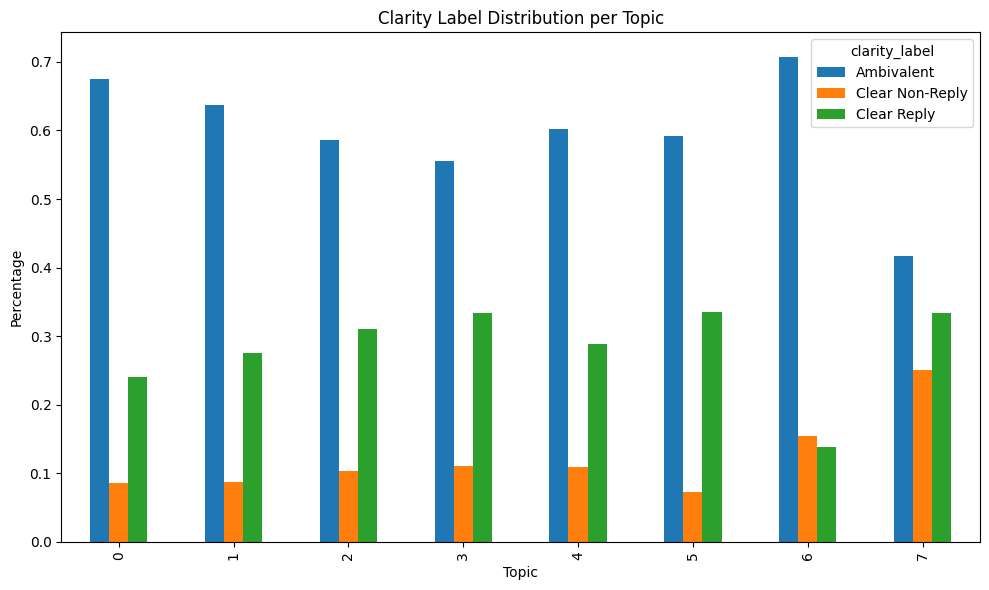

In [20]:
topic_col = 'topic'
topic_clarity = (
    df.groupby(topic_col)["clarity_label"]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)

topic_clarity.plot(kind="bar", figsize=(10,6))
plt.title("Clarity Label Distribution per Topic")
plt.ylabel("Percentage")
plt.xlabel("Topic")
plt.tight_layout()
plt.show()

There seems to be some discrepencies between topics regarding ambivalent percentage.

For example, topic No. 6 seems to be more ambivalent in general and less clear reply/non-reply answers, with topic words such as: white house, coronavirus, order and changes.
While topic No. 7 is more balanced with words such as: troops iraq, iran syria, presence, and iran

### 2.3 Sentiment analysis

Start by using `vaderSentiment` to classify the sentiment of every answer

In [21]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# filter out all null entries on answer:
df = df[df["answer"].notna() & (df["answer"].str.strip() != "")]

def vader_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    if scores["compound"] > 0.05:
        return "POSITIVE"
    elif scores["compound"] < -0.05:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

df["answer_sentiment"] = df["answer"].apply(vader_sentiment)
df["answer_sentiment"].value_counts()

answer_sentiment
POSITIVE    895
NEUTRAL     655
NEGATIVE    562
Name: count, dtype: int64

In [22]:
pd.crosstab(df["clarity_label"], df["answer_sentiment"], normalize="index")

answer_sentiment,NEGATIVE,NEUTRAL,POSITIVE
clarity_label,,,
Ambivalent,0.265940,0.292785,0.441275
Clear Non-Reply,0.311966,0.393162,0.294872
Clear Reply,0.250729,0.311953,0.437318


Generally, `Ambivalent`-label seem to have slightly higher positive sentiment, but thedistribution is fairly similar

In [23]:
pd.crosstab(df["evasion_label"], df["answer_sentiment"], normalize="index")

answer_sentiment,NEGATIVE,NEUTRAL,POSITIVE
evasion_label,,,
Claims ignorance,0.414634,0.268293,0.317073
Clarification,0.241935,0.612903,0.145161
Declining to answer,0.266667,0.355556,0.377778
Deflection,0.275304,0.242915,0.481781
Dodging,0.289544,0.369973,0.340483
Explicit,0.250729,0.311953,0.437318
General,0.213675,0.256410,0.529915
Implicit,0.262069,0.289655,0.448276
Partial/half-answer,0.312500,0.145833,0.541667


`Claims Ignorance`- and `Clarification`-labeled answers have higher percentage negative sentiment than others, while `PArtial/half-answer` and `Declining to answer` has generally higher positive sentiment.

### 2.4 Embedding analysis

In [24]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")  # fast & good
# or "all-mpnet-base-v2" for higher accuracy but slower

/opt/anaconda3/envs/nlp-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
df_clean = df[df["answer"].notna() & (df["answer"].str.strip() != "")]
embeddings = model.encode(df_clean["answer"].tolist(), show_progress_bar=True)

q_embeddings = model.encode(df_clean["question"].tolist(), show_progress_bar=True)

combined_text = df_clean["question"] + " [SEP] " + df_clean["answer"]
combined_embeddings = model.encode(combined_text.tolist(), show_progress_bar=True)

Batches: 100%|██████████| 66/66 [00:04<00:00, 15.68it/s]


In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_pca = pca.fit_transform(embeddings)

In [43]:

import umap.umap_ as umap

umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.1,
    metric="cosine"
)
X_umap = umap_model.fit_transform(embeddings)

In [44]:
from sklearn.cluster import KMeans

k = 10  # experiment with 6–15
kmeans = KMeans(n_clusters=k, random_state=42)
df_clean["embedding_cluster"] = kmeans.fit_predict(X_pca)

In [45]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric="euclidean")
df_clean["embedding_cluster"] = clusterer.fit_predict(X_pca)

/opt/anaconda3/envs/nlp-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/nlp-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


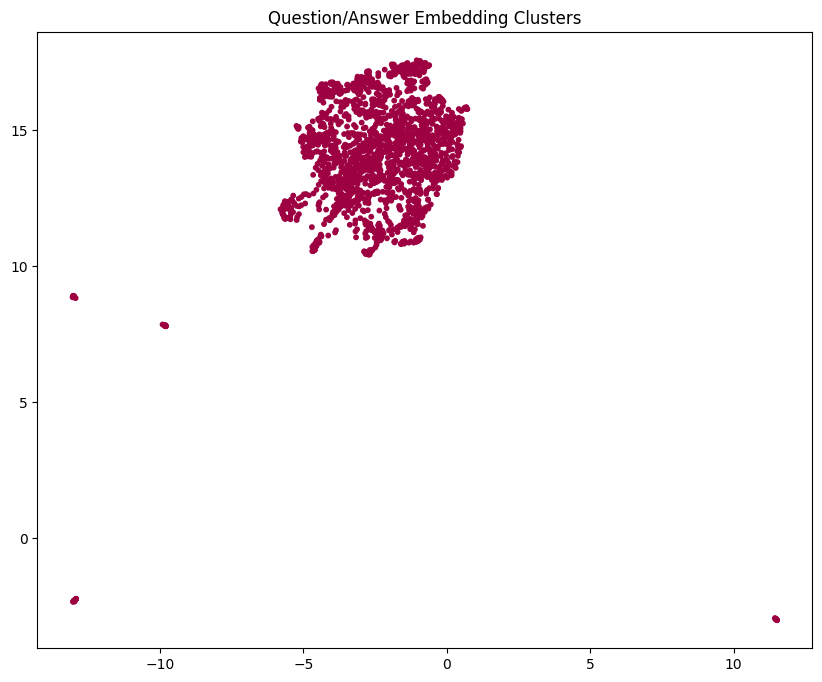

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(X_umap[:, 0], X_umap[:, 1],
            c=df_clean["embedding_cluster"],
            cmap="Spectral", s=10)
plt.title("Question/Answer Embedding Clusters")
plt.show()

In [48]:
df_clean.groupby("embedding_cluster")["question"].apply(lambda x: x.head(10))

embedding_cluster    
-1                 0     How would you respond to the accusation that t...
                   1     Do you think President Xi is being sincere abo...
                   2      Do you believe the country's slowdown and gro...
                   4      Is the President's engagement with Asian coun...
                   5                      Is there a danger of a cold war?
                   6                  When will the President meet Mr. Xi?
                   7      How concerned are you about this lack of cons...
                   8      Concerns about the lack of communication betw...
                   9      Inquiry about the reaction of Kyiv regarding ...
                   10                    What did you talk about with him?
Name: question, dtype: object

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

cluster_text = df_clean.groupby("embedding_cluster")["question"].apply(lambda x: " ".join(x))

vec = TfidfVectorizer(stop_words="english", max_features=30)
top_words = vec.fit_transform(cluster_text)

print(vec.get_feature_names_out())

['american' 'americans' 'change' 'china' 'congress' 'country' 'deal' 'did'
 'does' 'going' 'iran' 'korea' 'like' 'make' 'minister' 'mr' 'north'
 'people' 'president' 'prime' 'putin' 'question' 'regarding' 'russia'
 'say' 'states' 'think' 'trump' 'united' 'war']


In [51]:
df_clean.groupby("embedding_cluster")["clarity_label"].value_counts(normalize=True)

embedding_cluster  clarity_label  
-1                 Ambivalent         0.564394
                   Clear Reply        0.324811
                   Clear Non-Reply    0.110795
Name: proportion, dtype: float64

In [52]:
df_clean.groupby("embedding_cluster")["evasion_label"].value_counts(normalize=True)

embedding_cluster  evasion_label      
-1                 Explicit               0.324811
                   Dodging                0.176610
                   Implicit               0.137311
                   Deflection             0.116951
                   General                0.110795
                   Declining to answer    0.042614
                   Claims ignorance       0.038826
                   Clarification          0.029356
                   Partial/half-answer    0.022727
Name: proportion, dtype: float64

In [53]:
df_clean["date"] = pd.to_datetime(df_clean["date"])
df_clean.groupby([df_clean["date"].dt.year, "embedding_cluster"]).size()

date  embedding_cluster
2006  -1                    73
2007  -1                   177
2008  -1                   118
2009  -1                    89
2010  -1                    62
2011  -1                    72
2012  -1                    47
2013  -1                    89
2014  -1                    71
2015  -1                    61
2016  -1                    62
2017  -1                    37
2018  -1                   267
2019  -1                   158
2020  -1                   461
2021  -1                    89
2022  -1                   107
2023  -1                    72
dtype: int64